In [3]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import sys

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm
from torch.utils.data import random_split
from torchmetrics.regression import MeanSquaredError

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
from matplotlib.gridspec import GridSpec
from helpers.model_tool import ModelTool
from helpers.data_tool import CMSPlots


<h3>Model post-processing study</h3>

Testing pileup ml project neural network methods before integration

In [4]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [5]:
Path.cwd().parent

PosixPath('/home/paulius/vq_vae_experiments')

In [6]:
from helpers.data_tool import PixelPatchesDataset,\
                                CMSDataTool
from components.vqvae_management.components import CMSVQVAE
from helpers.models import ModelConfig                              

In [7]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
BITS_HIT = 25 
LOG_EVERY = 15

In [8]:
# TODO loaded from json file
config_data = {
    "model_name": "vq_vae",
    "model_folder": "build",
    "batch_size" : 64,
    "beta" : 0.31,
    "learning_rate" : 1e-3,
    "model_param_scale" : 5,
    "num_epochs" : 80,
    "channels" : 1,
    "hidden_channels" : 64,
    "num_embeddings" : 256,
    "kernel_size" : 4,
    "slope" : 0.1,
    "latent_dim" : 32,
    "residual_channels" : 32,
    "residual_layers" : 2
}

In [9]:
cms_data_tool = CMSDataTool()

In [10]:
# Loading data
pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:04<00:00, 242.14it/s]


In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
config_data["device"] = device
device

device(type='cuda')

<h3>Selecting event objects</h3>

In [12]:
event_train = events_train[0]
events_test = events_test[0]

In [13]:
patch_amount = cms_data_tool._get_patch_count(event_train)
total_hit_amount = len(event_train)

print(f"Total patch amount: {patch_amount}")
print(f"Total hits: {total_hit_amount}")

Total patch amount: 15857
Total hits: 48169


In [14]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

In [15]:
# Training set pre-processing


event_dataset = PixelPatchesDataset(
    event_train, 
    PATCH_SIZE, 
    transform
)
dataset_size = len(event_dataset)
train_size = int(0.8 * dataset_size)
test_size = dataset_size - train_size
batch_size = 64

train_dataset, test_dataset = random_split(
    event_dataset,
    [train_size, test_size]
)

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size,
    shuffle=True
)

print(f"Training set size: {len(train_dataset)}")

Training set size: 12685


In [16]:
config_data

{'model_name': 'vq_vae',
 'model_folder': 'build',
 'batch_size': 64,
 'beta': 0.31,
 'learning_rate': 0.001,
 'model_param_scale': 5,
 'num_epochs': 80,
 'channels': 1,
 'hidden_channels': 64,
 'num_embeddings': 256,
 'kernel_size': 4,
 'slope': 0.1,
 'latent_dim': 32,
 'residual_channels': 32,
 'residual_layers': 2,
 'device': device(type='cuda')}

In [17]:
config = ModelConfig(**config_data)

In [18]:
cms_vq_vae = CMSVQVAE(
    config=config, 
    train_loader=train_loader
)

In [19]:
print("Performing model training")
cms_vq_vae.fit(verbose=True)

Performing model training


Epoch (0/80) model VQ_LOSS + BCE Loss = 0.1817862650182978
Epoch (1/80) model VQ_LOSS + BCE Loss = 0.05925356819476914
Epoch (2/80) model VQ_LOSS + BCE Loss = 0.05018677577451246
Epoch (3/80) model VQ_LOSS + BCE Loss = 0.04643456630371324
Epoch (4/80) model VQ_LOSS + BCE Loss = 0.04423237271869003
Epoch (5/80) model VQ_LOSS + BCE Loss = 0.042840836316946164
Epoch (6/80) model VQ_LOSS + BCE Loss = 0.0417895574010347
Epoch (7/80) model VQ_LOSS + BCE Loss = 0.04117300448443123
Epoch (8/80) model VQ_LOSS + BCE Loss = 0.040663895651173954
Epoch (9/80) model VQ_LOSS + BCE Loss = 0.039932735900783056
Epoch (10/80) model VQ_LOSS + BCE Loss = 0.039459088236917204
Epoch (11/80) model VQ_LOSS + BCE Loss = 0.03911417644077809
Epoch (12/80) model VQ_LOSS + BCE Loss = 0.038736805244905866
Epoch (13/80) model VQ_LOSS + BCE Loss = 0.038457516889700935
Epoch (14/80) model VQ_LOSS + BCE Loss = 0.03811227702465489
Epoch (15/80) model VQ_LOSS + BCE Loss = 0.03786771157616047
Epoch (16/80) model VQ_LOSS + 

In [20]:
cms_vq_vae.display_gradients()

Showing model gradients
encoder.0.weight 0.0647040382027626
encoder.1.weight 0.00464260159060359
encoder.1.bias 0.01596730574965477
encoder.3.weight 0.05361972004175186
encoder.4.weight 0.003529197070747614
encoder.4.bias 0.0046028816141188145
encoder.6.weight 0.06677300482988358
encoder.7.weight 0.009596629999577999
encoder.7.bias 0.01232902705669403
encoder.8.stack.0.res_block.1.weight 0.019140399992465973
encoder.8.stack.0.res_block.3.weight 0.02706877700984478
encoder.8.stack.1.res_block.1.weight 0.017363835126161575
encoder.8.stack.1.res_block.3.weight 0.01543606910854578
vq_layer.embedding.weight 0.0008341787615790963
decoder.0.weight 0.02359713241457939
decoder.1.weight 0.003277294337749481
decoder.1.bias 0.0027081903535872698
decoder.2.stack.0.res_block.1.weight 0.008146951906383038
decoder.2.stack.0.res_block.3.weight 0.0077687473967671394
decoder.2.stack.1.res_block.1.weight 0.004139903467148542
decoder.2.stack.1.res_block.3.weight 0.004530949052423239
decoder.3.weight 0.0142

VQ VAE, BCE encoder average loss values over epochs


/home/paulius/vq_vae_experiments/helpers/data_tool.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


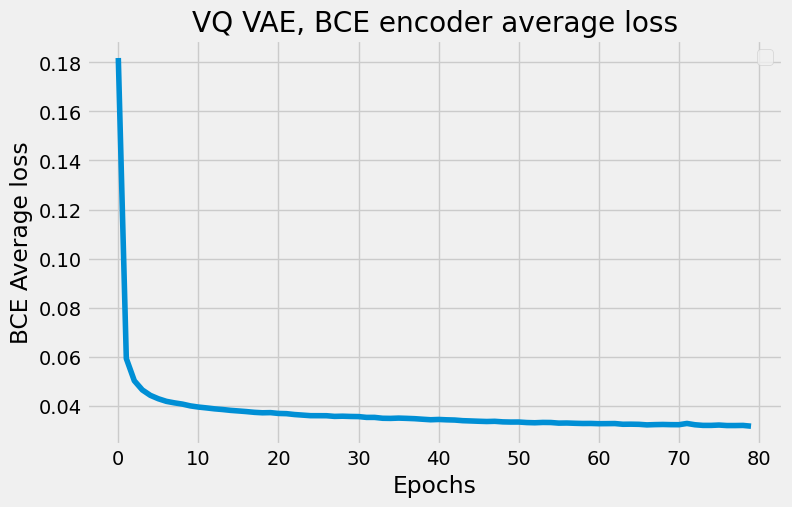

In [21]:
cms_vq_vae.plot_curve("vq_loss")

<h3>VQ-VAE testing with test data</h3>

In [22]:
cms_vq_vae.load_model()

Model loaded from path: build/vq_vae.pth


In [23]:
len(events_test)

24791

In [24]:
event_test_before = []
event_test_encoded = []
event_test_after = []

In [25]:
event_dataset = PixelPatchesDataset(
    events_test, 
    PATCH_SIZE, 
    transform
)
event_dataset_size = int(0.1 * len(event_dataset))
remaining = len(event_dataset) - event_dataset_size

event_test_small, _ = random_split(
    event_dataset,
    [event_dataset_size, remaining]
)

event_loader = DataLoader(
    dataset=event_test_small,
    batch_size=32
)

In [26]:
first_batch = next(iter(event_loader))

In [27]:
model_tool = ModelTool()
DISPLAY_LIMIT = 10

In [49]:
for patch in first_batch:
    patch = patch.float()
    patch = patch.to(device)
    patch = patch.unsqueeze(0)
    patch_np = model_tool._tensor_to_numpy(patch[0][0])
    _, encoder_vq_output = cms_vq_vae.transform(patch)
    
    encoder_vq_output_np = model_tool._tensor_to_numpy(
        encoder_vq_output[0][0]
    )
    decoder_vq_output = cms_vq_vae.inverse_transform(encoder_vq_output)
    decoder_vq_output_np = model_tool._tensor_to_numpy(
        decoder_vq_output[0][0]
    )
    
    if len(event_test_before) < DISPLAY_LIMIT:
        event_test_before.append(patch_np)
        event_test_encoded.append(encoder_vq_output_np)
        event_test_after.append(decoder_vq_output_np)

if len(event_test_before) >= DISPLAY_LIMIT:
    print(f"Selected {len(event_test_before)} patches for analysis")
    

Selected 10 patches for analysis


In [50]:
decoder_vq_output_np.shape

(8, 8)

TypeError: Invalid shape (2, 2, 32, 1) for image data

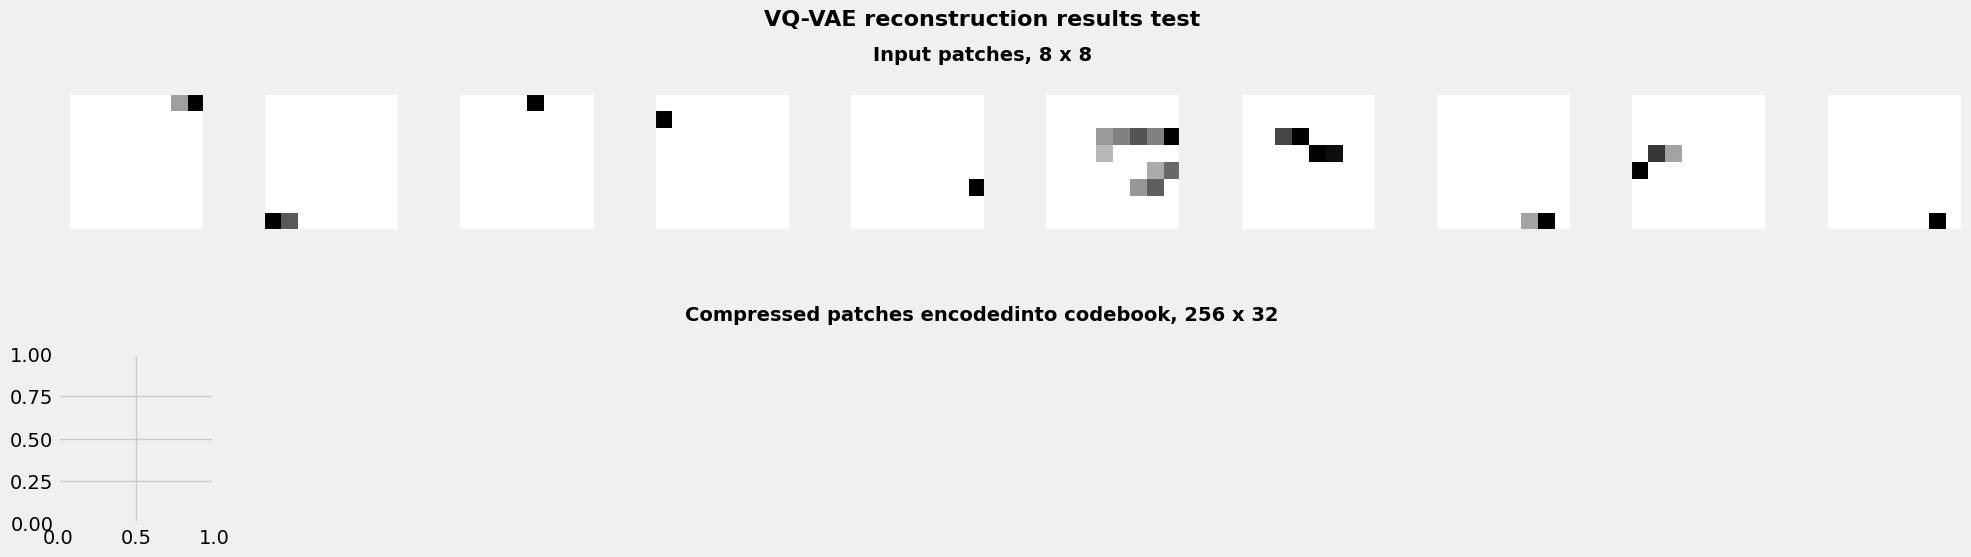

In [51]:
# Test dataset plotting part
patch_rows = [
    (event_test_before, "Input patches, 8 x 8"),
    (event_test_encoded, f"Compressed patches encoded"
     f"into codebook, {config.num_embeddings} x {config.latent_dim}"),
    (event_test_after, "Output patches (Received from VQ-VAE)")
]
cms_plots = CMSPlots()
cms_plots.plot_patches(patch_rows, "VQ-VAE reconstruction results test")